# Analysis on the Budepest AirBnB Weekday and Weekend Data

## Imports

In [30]:
install.packages("ggcorrplot")

Installing package into ‘/home/jupyter/R/x86_64-pc-linux-gnu-library/4.5’
(as ‘lib’ is unspecified)



In [31]:
library(tidyverse)
library(repr)
library(ggcorrplot)

## Introduction

Recent studies have shown that short-term rental markets in major European cities exhibit strong spatial and economic variation, which can shape pricing patterns in Airbnb listings (Huang & Benner, 2020). Our dataset contains 4,022 Airbnb listings from Budapest, recorded across both weekdays and weekends, with 19 variables describing listing characteristics, host attributes, and location features; we also include an indicator for whether the listing was observed on a weekend. Using this dataset, our goal is to determine which factors most strongly influence the total price of an Airbnb listing. Because we aim to understand how price changes in relation to specific explanatory variables, rather than focusing on prediction, this is an inference-focused analysis.

## Research Question

Is renting an AirBnB in Budapest more expensive on weekends vs weekdays?

In [48]:
# Reading the data and cleaning the data
budapest_weekday <- read_csv("data/budapest_weekdays.csv") 
budapest_weekend <- read_csv("data/budapest_weekends.csv") 

budapest_weekday <- budapest_weekday %>%
    select(- "...1") %>%
    mutate(source_budapest_weekday = TRUE)

budapest_weekend <- budapest_weekend %>%
    select(- "...1") %>%
    mutate(source_budapest_weekdend = TRUE)

budapest <- full_join(budapest_weekday, budapest_weekend) %>%
    mutate(day_type = case_when(
    source_budapest_weekday & source_budapest_weekdend ~ "both",
    source_budapest_weekday ~ "Weekday",
    source_budapest_weekdend ~ "Weekend"
  )) %>%
  select(-source_budapest_weekday, -source_budapest_weekdend, -room_shared, -room_private, -attr_index_norm, -rest_index_norm)

New names:
• `` -> `...1`
Rows: 2074 Columns: 20
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): room_type
dbl (16): ...1, realSum, person_capacity, multi, biz, cleanliness_rating, gu...
lgl  (3): room_shared, room_private, host_is_superhost

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
New names:
• `` -> `...1`
Rows: 1948 Columns: 20
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): room_type
dbl (16): ...1, realSum, person_capacity, multi, biz, cleanliness_rating, gu...
lgl  (3): room_shared, room_private, host_is_superhost

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Joining with `by = join_by(realSum, room_type, room_shared, room_private,
person_capacity,

## Exploratory Data Analysis

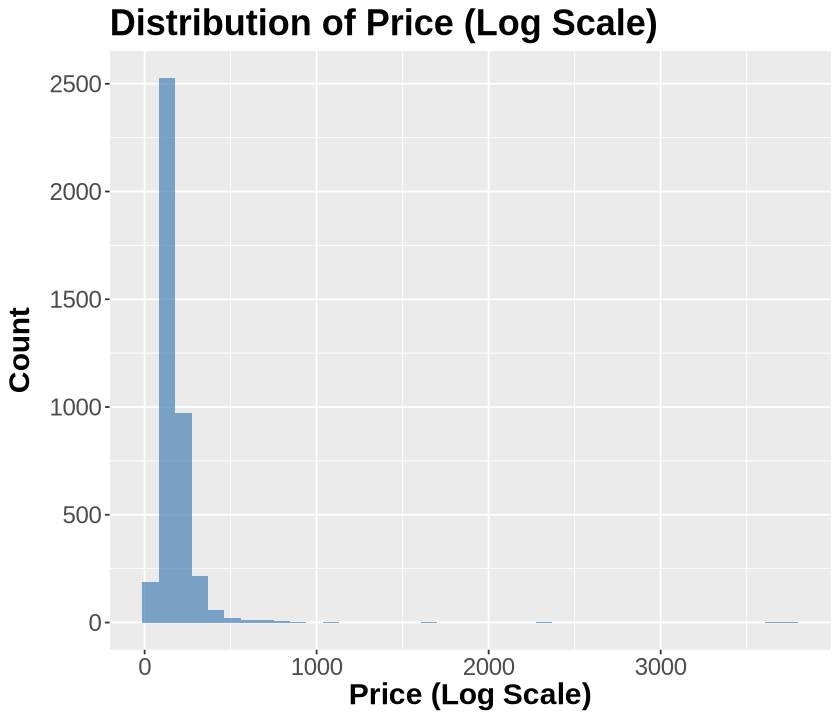

In [59]:
# Distribution of the listing prices 
dist <- ggplot(budapest, aes(x = realSum)) +
geom_histogram(bins = 40, fill = "steelblue", alpha = 0.7) +
labs(title = "Distribution of Price (Log Scale)",
x = "Price (Log Scale)", y = "Count") +
  theme(
    text = element_text(size = 18),
    plot.title = element_text(face = "bold"),
    axis.title = element_text(face = "bold")
  )

dist

From the histogram above, we can see that the prices of the listings are heavily right-skewed. A log transformation can effectively reduce the skewness and makes the price data more suitable for multiple linear regression modeling.

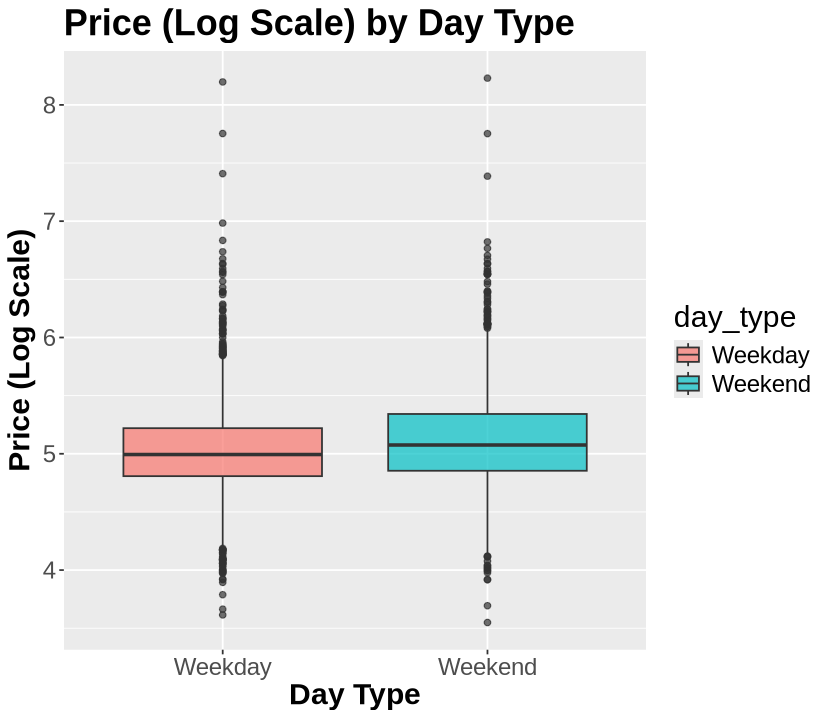

In [51]:
# How price differs across room types using log-transformed values
box <- ggplot(budapest, aes(x = day_type, y = log(realSum), fill = day_type)) +
geom_boxplot(alpha = 0.7) +
labs(title = "Price (Log Scale) by Day Type",
x = "Day Type", y = "Price (Log Scale)") +
  theme(
    text = element_text(size = 18),
    plot.title = element_text(face = "bold"),
    axis.title = element_text(face = "bold")
  )

box

The log-scaled boxplot reveals a subtle but distinct upward shift in pricing for weekend listings, with the median weekend price sitting visibly higher than its weekday counterpart. Both distributions maintain a similar interquartile spread and feature numerous high-price outliers, indicating that while baseline rates rise on weekends, extreme luxury pricing exists regardless of the day. This visual confirmation supports the hypothesis of a general weekend pricing premium, validating day_type as a meaningful predictor for regression models.

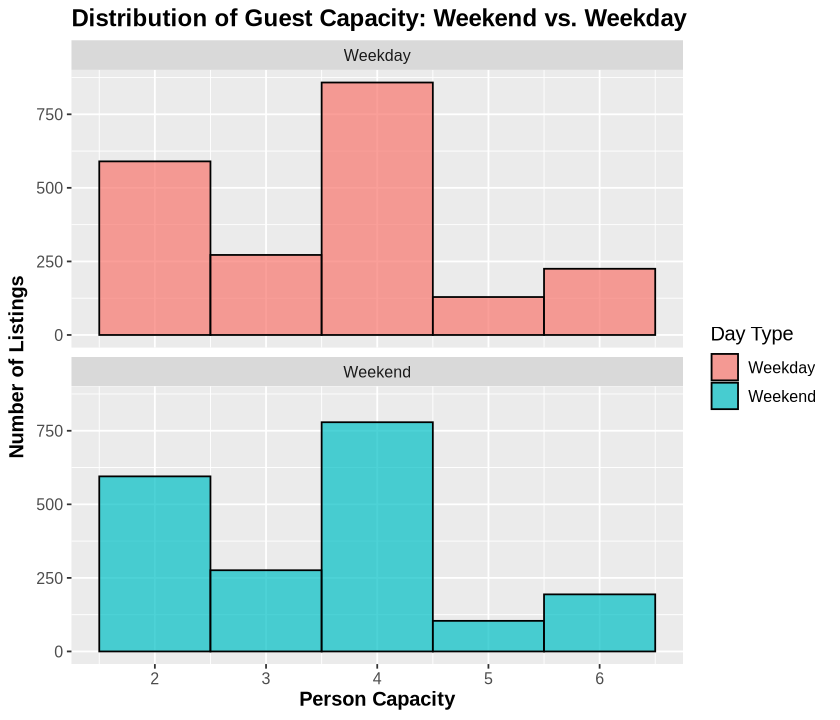

In [52]:
ggplot(budapest, aes(x = person_capacity, fill = day_type)) +
  # Create the histogram. 
  # 'binwidth = 1' is ideal since capacity is measured in whole numbers.
  # 'color = "black"' adds an outline to the bars to make them distinct.
  geom_histogram(binwidth = 1, color = "black", alpha = 0.7) +
  
  # This splits the plot into multiple panels based on 'day_type'
  # 'ncol = 1' stacks them vertically so the x-axes align perfectly for comparison
  facet_wrap(~ day_type, ncol = 1) +
# Clean up titles and labels
  labs(
    title = "Distribution of Guest Capacity: Weekend vs. Weekday",
    x = "Person Capacity",
    y = "Number of Listings",
    fill = "Day Type" # Adds a legend for the fill colors
  ) +
theme(
    text = element_text(size = 12),
    plot.title = element_text(face = "bold"),
    axis.title = element_text(face = "bold")
  )

The visualization above demonstrates that the distribution of guest capacity is virtually identical between weekday and weekend listings, with accommodations for four and two people being the most prevalent. Because there is no noticeable shift toward larger group bookings on the weekends, we can largely rule out guest capacity as a confounding variable in our pricing comparison. This similarity suggests that if weekend prices are indeed higher, the increase is likely driven by other factors rather than a change in the physical size of the properties being rented.

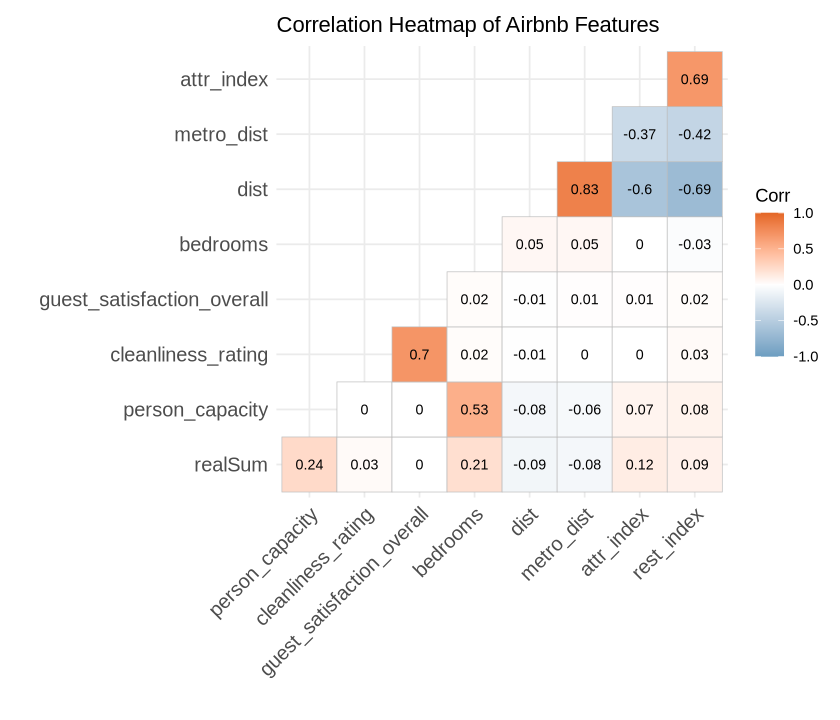

In [64]:
airbnb_numeric <- budapest %>%
  select(realSum, person_capacity, cleanliness_rating, 
         guest_satisfaction_overall, bedrooms, dist, 
         metro_dist, attr_index, rest_index)

corr_matrix <- cor(airbnb_numeric)

ggcorrplot(corr_matrix, 
           method = "square",       
           type = "lower", # Shows only the lower triangle to remove redundant duplicates
           lab = TRUE,              
           lab_size = 3,            
           colors = c("#6D9EC1", "white", "#E46726"), # Blue (negative) to Red (positive) gradient
           title = "Correlation Heatmap of Airbnb Features")

The heatmap reveals significant multicollinearity among several predictors, most notably the strong positive correlation between distance to the city center and distance to the nearest metro, as well as between cleanliness and overall guest satisfaction. Meanwhile, the target variable realSum exhibits only weak positive correlations with size metrics like person capacity and bedrooms, suggesting that pricing is not heavily dominated by any single continuous feature. Flagging these highly correlated predictor pairs early is a critical step, as they will likely inflate VIF and cause coefficient instability when fitting a multiple linear regression model later on.